In [ ]:
jjj# Install the necessary libraries
!pip install transformer_lens sae_lens
!pip install torch

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 10.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 195.2/195.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.1/288.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

KeyboardInterrupt: 

In [ ]:
import torch
import torch.nn.functional as F
from transformer_lens import HookedTransformer
from sae_lens import SAE

# 1. Device Setup (Colab GPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 2. Load GPT-2 Small
print("Loading GPT-2 Small...")
model = HookedTransformer.from_pretrained("gpt2-small", device=device)

# 3. Load the Sparse Autoencoder (SAE)
# We are using a pre-trained SAE on the residual stream of Layer 8
print("Loading SAE for Layer 8...")
sae, cfg_dict, sparsity = SAE.from_pretrained(
    release="gpt2-small-res-jb",
    sae_id="blocks.8.hook_resid_pre",
    device=device
)
sae = sae.to(device) # Ensure SAE is on the GPU
print("Models loaded successfully!")

Using device: cpu
Loading GPT-2 Small...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

...

cfg.json: 0.00B [00:00, ?B/s]

blocks.8.hook_resid_pre/sae_weights.safe(…):   0%|          | 0.00/151M [00:00<?, ?B/s]

blocks.8.hook_resid_pre/sparsity.safeten(…):   0%|          | 0.00/98.4k [00:00<?, ?B/s]

Models loaded successfully!


/usr/local/lib/python3.12/dist-packages/sae_lens/saes/sae.py:248: UserWarning: 
This SAE has non-empty model_from_pretrained_kwargs. 
For optimal performance, load the model like so:
model = HookedSAETransformer.from_pretrained_no_processing(..., **cfg.model_from_pretrained_kwargs)
  warnings.warn(
/tmp/ipython-input-626084889.py:17: DeprecationWarning: Unpacking SAE objects is deprecated. SAE.from_pretrained() now returns only the SAE object. Use SAE.from_pretrained_with_cfg_and_sparsity() to get the config dict and sparsity as well.
  sae, cfg_dict, sparsity = SAE.from_pretrained(


In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim

def deep_dream_robust_batch(feature_idx, batch_size=64, steps=100, lr=0.1, reg_weight=1.0):
    print(f"\n=== Robust Dreaming for Feature #{feature_idx} ===")

    # 1. Robust Hook Name Detection
    if hasattr(sae.cfg, "hook_name"): hook_name = sae.cfg.hook_name
    elif hasattr(sae.cfg, "hook_point"): hook_name = sae.cfg.hook_point
    else: hook_name = "blocks.8.hook_resid_pre"
    print(f"Target Hook: {hook_name}")

    # 2. BATCH SEARCH (The Fix)
    # Generate 64 random "soft prompts" at once to find a spark
    seq_len = 6
    d_model = model.cfg.d_model

    print(f"Scanning {batch_size} random prompts to find a spark...")

    # Initialize a batch of noise
    # We use a slightly larger initialization scale (0.2) to help find active regions
    batch_noise = torch.randn(batch_size, seq_len, d_model).to(device) * 0.2

    # Container to catch activations
    batch_activations = []

    # Hooks for Batch Search
    def batch_embedding_hook(resid, hook):
        # resid: [batch, seq, d_model] -> Replace with our noise
        return batch_noise

    def batch_caching_hook(resid, hook):
        batch_activations.append(resid)
        return resid

    # Run the model (Manual Mode)
    with torch.no_grad():
        model.run_with_hooks(
            torch.zeros(batch_size, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', batch_embedding_hook),
                (hook_name, batch_caching_hook)
            ]
        )

    # Analyze results
    layer_acts = batch_activations[0] # [batch, seq, d_model]
    feature_acts = sae.encode(layer_acts) # [batch, seq, d_sae]

    # Find the best candidate in the batch
    # We look for the sample that has the highest MAX activation across the sequence
    act_per_item = feature_acts[:, :, feature_idx].max(dim=1).values
    best_val, best_idx = torch.max(act_per_item, dim=0)

    print(f"Best initial activation: {best_val.item():.4f}")

    if best_val.item() <= 0.001:
        print("❌ Feature is dead (0.0) for all random inputs. Try a different feature index (e.g., 0, 10, 15).")
        return None

    # 3. SELECT THE WINNER
    print(f"Selected candidate #{best_idx.item()}. Optimizing...")

    # Clone the winner to become the trainable parameter
    # Shape: [1, seq, d_model]
    best_embedding = batch_noise[best_idx].unsqueeze(0).detach().clone()
    soft_embeddings = torch.nn.Parameter(best_embedding, requires_grad=True)

    optimizer = torch.optim.Adam([soft_embeddings], lr=lr)

    # 4. OPTIMIZATION LOOP
    for step in range(steps):
        optimizer.zero_grad()

        opt_activations = []

        # Hook: Replace Embedding
        def single_embed_hook(resid, hook):
            return soft_embeddings

        # Hook: Catch Activation
        def single_caching_hook(resid, hook):
            opt_activations.append(resid)
            return resid

        # Forward Pass
        model.run_with_hooks(
            torch.zeros(1, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', single_embed_hook),
                (hook_name, single_caching_hook)
            ]
        )

        layer_acts = opt_activations[0]
        feature_acts = sae.encode(layer_acts)

        # Loss 1: Maximize Feature
        target_act = feature_acts[0, :, feature_idx].mean()
        loss_maximize = -target_act

        # Loss 2: Regularization (Coherence)
        norm_soft = F.normalize(soft_embeddings, p=2, dim=-1)
        norm_vocab = F.normalize(model.W_E, p=2, dim=-1)
        cosine_sim = torch.matmul(norm_soft, norm_vocab.T)
        best_match, _ = torch.max(cosine_sim, dim=-1)

        # Ramping Reg: Start at 0, ramp up to reg_weight
        current_reg = reg_weight * (step / steps)
        loss_coherence = 1.0 - best_match.mean()

        total_loss = loss_maximize + (current_reg * loss_coherence)

        total_loss.backward()
        optimizer.step()

        # Logging
        if step % 20 == 0 or step == steps - 1:
            sim = torch.matmul(norm_soft, norm_vocab.T)
            best_tokens = torch.argmax(sim, dim=-1)
            text = model.to_string(best_tokens)
            print(f"Step {step:03} | Act: {target_act.item():.4f} | Loss: {total_loss.item():.4f} | Text: '{text}'")

    return text

# --- RUN EXPERIMENT ---
# Feature 1620 is tricky. Let's try Feature 10 first (usually punctuation/common).
# If 1620 fails again, switch to 10 or 0.
final_text = deep_dream_robust_batch(feature_idx=1620, batch_size=128, steps=100, lr=0.1, reg_weight=5.0)


=== Robust Dreaming for Feature #1620 ===
Target Hook: blocks.8.hook_resid_pre
Scanning 128 random prompts to find a spark...
Best initial activation: 3.4618
Selected candidate #6. Optimizing...
Step 000 | Act: 0.5770 | Loss: -0.5770 | Text: '['orable Centauri Amazon AA Newt burner']'
Step 020 | Act: 651.2156 | Loss: -650.4848 | Text: '[' envelop surprises surprise surprise surprise surprise']'
Step 040 | Act: 1011.6824 | Loss: -1010.2690 | Text: '[' Surprise surprise surprise surprise surprise surprise']'
Step 060 | Act: 1130.1144 | Loss: -1127.9971 | Text: '[' surprise surprise surprise surprise surprise surprise']'
Step 080 | Act: 1180.9111 | Loss: -1178.0652 | Text: '[' surprise surprise surprise surprise surprise surprise']'
Step 099 | Act: 1221.9039 | Loss: -1218.3225 | Text: '[' surprise surprise surprise surprise surprise surprise']'


In [ ]:
import torch
import torch.nn.functional as F
import torch.optim as optim

def deep_dream_last_token_robust(feature_idx, steps=100, lr=0.05, reg_weight=1.0, div_weight=100.0):
    print(f"\n=== Context Dreaming for Feature #{feature_idx} ===")

    # 1. Setup Hook Name
    if hasattr(sae.cfg, "hook_name"): hook_name = sae.cfg.hook_name
    elif hasattr(sae.cfg, "hook_point"): hook_name = sae.cfg.hook_point
    else: hook_name = "blocks.8.hook_resid_pre"

    seq_len = 8
    batch_size = 32
    d_model = model.cfg.d_model

    # --- PHASE 1: BATCH SEARCH (MANUAL HOOKS) ---
    print(f"Scanning {batch_size} seeds (Manual Mode)...")

    # Create batch noise
    batch_noise = torch.randn(batch_size, seq_len, d_model).to(device) * 0.2

    # Container to catch activations
    batch_activations = []

    # Hooks for Batch Search
    def batch_embed_hook(resid, hook):
        # Replace the model's embeddings with our noise batch
        return batch_noise

    def batch_cache_hook(resid, hook):
        # Capture the output at the target layer
        batch_activations.append(resid)
        return resid

    # Run Model (No Gradients)
    with torch.no_grad():
        model.run_with_hooks(
            torch.zeros(batch_size, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', batch_embed_hook),
                (hook_name, batch_cache_hook)
            ]
        )

    # Analyze Results
    # batch_activations[0] is [batch, seq, d_model]
    feature_acts = sae.encode(batch_activations[0])

    # Target: LAST TOKEN ONLY (Index -1)
    last_token_acts = feature_acts[:, -1, feature_idx]
    best_val, best_idx = torch.max(last_token_acts, dim=0)

    print(f"Best initial last-token activation: {best_val.item():.4f}")

    if best_val.item() <= 0.001:
        print("❌ Feature is dead. Try another index (0, 10, 15).")
        return None

    # --- PHASE 2: OPTIMIZE WINNER (MANUAL HOOKS) ---
    print(f"Optimizing Candidate #{best_idx.item()}...")

    # Set up trainable parameter
    best_embedding = batch_noise[best_idx].unsqueeze(0).detach().clone()
    soft_embeddings = torch.nn.Parameter(best_embedding, requires_grad=True)
    optimizer = torch.optim.Adam([soft_embeddings], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()

        opt_activations = []

        # Hooks for Optimization
        def embed_hook(resid, hook): return soft_embeddings
        def cache_hook(resid, hook):
            opt_activations.append(resid)
            return resid

        # Forward Pass
        model.run_with_hooks(
            torch.zeros(1, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', embed_hook),
                (hook_name, cache_hook)
            ]
        )

        # Calculate Losses
        layer_acts = opt_activations[0]
        feature_acts = sae.encode(layer_acts)

        # A. Maximize Last Token
        target_act = feature_acts[0, -1, feature_idx]
        loss_max = -target_act

        # B. Regularization (English Coherence)
        norm_soft = F.normalize(soft_embeddings, p=2, dim=-1)
        norm_vocab = F.normalize(model.W_E, p=2, dim=-1)
        sim_matrix = torch.matmul(norm_soft, norm_vocab.T)
        best_match, _ = torch.max(sim_matrix, dim=-1)
        current_reg = reg_weight * (step / steps)
        loss_reg = 1.0 - best_match.mean()

        # C. Diversity Loss (No Repetition)
        seq_vectors = F.normalize(soft_embeddings[0], p=2, dim=-1)
        self_sim_matrix = torch.matmul(seq_vectors, seq_vectors.T)
        mask = torch.eye(seq_len).to(device)
        # Penalize if tokens are too similar to each other
        loss_div = (self_sim_matrix * (1 - mask)).mean()

        # Combine
        total_loss = loss_max + (current_reg * loss_reg) + (div_weight * loss_div)
        total_loss.backward()
        optimizer.step()

        if step % 25 == 0 or step == steps - 1:
            best_tokens = torch.argmax(sim_matrix, dim=-1)
            text = model.to_string(best_tokens)
            print(f"Step {step:03} | Act: {target_act.item():.1f} | DivLoss: {loss_div.item():.4f} | Text: {text}")

    return text
# Run on "Surprise" (1620)
# div_weight is high (100.0) to force the model to stop repeating "surprise"
deep_dream_last_token_robust(feature_idx=1650, steps=150, reg_weight=1.0, div_weight=100.0)


=== Context Dreaming for Feature #1650 ===
Scanning 32 seeds (Manual Mode)...
Best initial last-token activation: 0.3335
Optimizing Candidate #11...
Step 000 | Act: 0.3 | DivLoss: -0.0055 | Text: [' robbing homes scoreboard by Lite pm increaseLEASE']
Step 025 | Act: 0.0 | DivLoss: -0.1233 | Text: [' robbing Veomaly boutse UID sit other']
Step 050 | Act: 0.0 | DivLoss: -0.1248 | Text: [' robbing Veomaly boutse UID sit other']
Step 075 | Act: 0.0 | DivLoss: -0.1250 | Text: [' robbing Veomaly boutse UID sit other']
Step 100 | Act: 0.0 | DivLoss: -0.1250 | Text: [' robbing Veomaly boutse UID sit other']
Step 125 | Act: 0.0 | DivLoss: -0.1250 | Text: [' robbing Veomaly boutse UID sit other']
Step 149 | Act: 0.0 | DivLoss: -0.1250 | Text: [' robbing Veomaly boutse UID sit other']


[' robbing Veomaly boutse UID sit other']

In [ ]:

import torch
import torch.nn.functional as F
import torch.optim as optim

def deep_dream_last_token_robust(feature_idx, steps=100, lr=0.05, reg_weight=1.0, div_weight=100.0):
    print(f"\n=== Context Dreaming for Feature #{feature_idx} ===")

    # 1. Setup Hook Name
    if hasattr(sae.cfg, "hook_name"): hook_name = sae.cfg.hook_name
    elif hasattr(sae.cfg, "hook_point"): hook_name = sae.cfg.hook_point
    else: hook_name = "blocks.8.hook_resid_pre"

    seq_len = 8
    batch_size = 32
    d_model = model.cfg.d_model

    # --- PHASE 1: BATCH SEARCH (MANUAL HOOKS) ---
    print(f"Scanning {batch_size} seeds (Manual Mode)...")

    # Create batch noise
    batch_noise = torch.randn(batch_size, seq_len, d_model).to(device) * 0.2

    # Container to catch activations
    batch_activations = []

    # Hooks for Batch Search
    def batch_embed_hook(resid, hook):
        # Replace the model's embeddings with our noise batch
        return batch_noise

    def batch_cache_hook(resid, hook):
        # Capture the output at the target layer
        batch_activations.append(resid)
        return resid

    # Run Model (No Gradients)
    with torch.no_grad():
        model.run_with_hooks(
            torch.zeros(batch_size, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', batch_embed_hook),
                (hook_name, batch_cache_hook)
            ]
        )

    # Analyze Results
    # batch_activations[0] is [batch, seq, d_model]
    feature_acts = sae.encode(batch_activations[0])

    # Target: LAST TOKEN ONLY (Index -1)
    last_token_acts = feature_acts[:, -1, feature_idx]
    best_val, best_idx = torch.max(last_token_acts, dim=0)

    print(f"Best initial last-token activation: {best_val.item():.4f}")

    if best_val.item() <= 0.001:
        print("❌ Feature is dead. Try another index (0, 10, 15).")
        return None

    # --- PHASE 2: OPTIMIZE WINNER (MANUAL HOOKS) ---
    print(f"Optimizing Candidate #{best_idx.item()}...")

    # Set up trainable parameter
    best_embedding = batch_noise[best_idx].unsqueeze(0).detach().clone()
    soft_embeddings = torch.nn.Parameter(best_embedding, requires_grad=True)
    optimizer = torch.optim.Adam([soft_embeddings], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()

        opt_activations = []

        # Hooks for Optimization
        def embed_hook(resid, hook): return soft_embeddings
        def cache_hook(resid, hook):
            opt_activations.append(resid)
            return resid

        # Forward Pass
        model.run_with_hooks(
            torch.zeros(1, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', embed_hook),
                (hook_name, cache_hook)
            ]
        )

        # Calculate Losses
        layer_acts = opt_activations[0]
        feature_acts = sae.encode(layer_acts)

        # A. Maximize Last Token
        target_act = feature_acts[0, -1, feature_idx]
        loss_max = -target_act

        # B. Regularization (English Coherence)
        norm_soft = F.normalize(soft_embeddings, p=2, dim=-1)
        norm_vocab = F.normalize(model.W_E, p=2, dim=-1)
        sim_matrix = torch.matmul(norm_soft, norm_vocab.T)
        best_match, _ = torch.max(sim_matrix, dim=-1)
        current_reg = reg_weight * (step / steps)
        loss_reg = 1.0 - best_match.mean()

        # C. Diversity Loss (No Repetition)
        seq_vectors = F.normalize(soft_embeddings[0], p=2, dim=-1)
        self_sim_matrix = torch.matmul(seq_vectors, seq_vectors.T)
        mask = torch.eye(seq_len).to(device)
        # Penalize if tokens are too similar to each other
        loss_div = (self_sim_matrix * (1 - mask)).mean()

        # Combine
        total_loss = loss_max + (current_reg * loss_reg) + (div_weight * loss_div)
        total_loss.backward()
        optimizer.step()

        if step % 25 == 0 or step == steps - 1:
            best_tokens = torch.argmax(sim_matrix, dim=-1)
            text = model.to_string(best_tokens)
            print(f"Step {step:03} | Act: {target_act.item():.1f} | DivLoss: {loss_div.item():.4f} | Text: {text}")

    return text
# Run on "Sucking" (1620)
# div_weight is high (100.0) to force the model to stop repeating "surprise"
deep_dream_last_token_robust(feature_idx=1600, steps=150, reg_weight=1.0, div_weight=100.0)


=== Context Dreaming for Feature #1600 ===
Scanning 32 seeds (Manual Mode)...
Best initial last-token activation: 0.3342
Optimizing Candidate #27...
Step 000 | Act: 0.3 | DivLoss: 0.0118 | Text: [' Problems Reactmarried Boost LateIAS Meat Vec']
Step 025 | Act: 930.9 | DivLoss: -0.0427 | Text: [' solutionsstand ND DR multouringhash sucking']
Step 050 | Act: 1209.9 | DivLoss: -0.0493 | Text: [' Westminsterstand Crom newly Modern Bringing unamb sucking']
Step 075 | Act: 1296.0 | DivLoss: -0.0640 | Text: ['207 sounding ND newly Modern390 bold sucking']
Step 100 | Act: 1342.3 | DivLoss: -0.0721 | Text: ['207 sounding Dow newly Modern sucking no sucking']
Step 125 | Act: 1392.0 | DivLoss: -0.0772 | Text: ['96 sounding Dow loop Modern sucking no sucking']
Step 149 | Act: 1417.6 | DivLoss: -0.0813 | Text: ['96 sounding Dow loop Modern sucking no sucking']


['96 sounding Dow loop Modern sucking no sucking']

In [ ]:

import torch
import torch.nn.functional as F
import torch.optim as optim

def deep_dream_last_token_robust(feature_idx, steps=100, lr=0.05, reg_weight=1.0, div_weight=100.0):
    print(f"\n=== Context Dreaming for Feature #{feature_idx} ===")

    # 1. Setup Hook Name
    if hasattr(sae.cfg, "hook_name"): hook_name = sae.cfg.hook_name
    elif hasattr(sae.cfg, "hook_point"): hook_name = sae.cfg.hook_point
    else: hook_name = "blocks.8.hook_resid_pre"

    seq_len = 8
    batch_size = 32
    d_model = model.cfg.d_model

    # --- PHASE 1: BATCH SEARCH (MANUAL HOOKS) ---
    print(f"Scanning {batch_size} seeds (Manual Mode)...")

    # Create batch noise
    batch_noise = torch.randn(batch_size, seq_len, d_model).to(device) * 0.2

    # Container to catch activations
    batch_activations = []

    # Hooks for Batch Search
    def batch_embed_hook(resid, hook):
        # Replace the model's embeddings with our noise batch
        return batch_noise

    def batch_cache_hook(resid, hook):
        # Capture the output at the target layer
        batch_activations.append(resid)
        return resid

    # Run Model (No Gradients)
    with torch.no_grad():
        model.run_with_hooks(
            torch.zeros(batch_size, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', batch_embed_hook),
                (hook_name, batch_cache_hook)
            ]
        )

    # Analyze Results
    # batch_activations[0] is [batch, seq, d_model]
    feature_acts = sae.encode(batch_activations[0])

    # Target: LAST TOKEN ONLY (Index -1)
    last_token_acts = feature_acts[:, -1, feature_idx]
    best_val, best_idx = torch.max(last_token_acts, dim=0)

    print(f"Best initial last-token activation: {best_val.item():.4f}")

    if best_val.item() <= 0.001:
        print("❌ Feature is dead. Try another index (0, 10, 15).")
        return None

    # --- PHASE 2: OPTIMIZE WINNER (MANUAL HOOKS) ---
    print(f"Optimizing Candidate #{best_idx.item()}...")

    # Set up trainable parameter
    best_embedding = batch_noise[best_idx].unsqueeze(0).detach().clone()
    soft_embeddings = torch.nn.Parameter(best_embedding, requires_grad=True)
    optimizer = torch.optim.Adam([soft_embeddings], lr=lr)

    for step in range(steps):
        optimizer.zero_grad()

        opt_activations = []

        # Hooks for Optimization
        def embed_hook(resid, hook): return soft_embeddings
        def cache_hook(resid, hook):
            opt_activations.append(resid)
            return resid

        # Forward Pass
        model.run_with_hooks(
            torch.zeros(1, seq_len).long().to(device),
            fwd_hooks=[
                ('hook_embed', embed_hook),
                (hook_name, cache_hook)
            ]
        )

        # Calculate Losses
        layer_acts = opt_activations[0]
        feature_acts = sae.encode(layer_acts)

        # A. Maximize Last Token
        target_act = feature_acts[0, -1, feature_idx]
        loss_max = -target_act

        # B. Regularization (English Coherence)
        norm_soft = F.normalize(soft_embeddings, p=2, dim=-1)
        norm_vocab = F.normalize(model.W_E, p=2, dim=-1)
        sim_matrix = torch.matmul(norm_soft, norm_vocab.T)
        best_match, _ = torch.max(sim_matrix, dim=-1)
        current_reg = reg_weight * (step / steps)
        loss_reg = 1.0 - best_match.mean()

        # C. Diversity Loss (No Repetition)
        seq_vectors = F.normalize(soft_embeddings[0], p=2, dim=-1)
        self_sim_matrix = torch.matmul(seq_vectors, seq_vectors.T)
        mask = torch.eye(seq_len).to(device)
        # Penalize if tokens are too similar to each other
        loss_div = (self_sim_matrix * (1 - mask)).mean()

        # Combine
        total_loss = loss_max + (current_reg * loss_reg) + (div_weight * loss_div)
        total_loss.backward()
        optimizer.step()

        if step % 25 == 0 or step == steps - 1:
            best_tokens = torch.argmax(sim_matrix, dim=-1)
            text = model.to_string(best_tokens)
            print(f"Step {step:03} | Act: {target_act.item():.1f} | DivLoss: {loss_div.item():.4f} | Text: {text}")

    return text
# Run on "Sucking" (1620)
# div_weight is high (100.0) to force the model to stop repeating "surprise"

deep_dream_last_token_robust(feature_idx=700, steps=150, reg_weight=1.0, div_weight=100.0)


=== Context Dreaming for Feature #700 ===
Scanning 32 seeds (Manual Mode)...
Best initial last-token activation: 0.0000
❌ Feature is dead. Try another index (0, 10, 15).


In [ ]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from tqdm import tqdm

# --- CONFIGURATION ---
START_FEATURE = 0
END_FEATURE = 100  # Scan first 100 features for the pilot
BATCH_SIZE = 64    # Number of random seeds per feature (The "Spark" probe)
OPT_STEPS = 50     # Short optimization to test "Gain"
LR = 0.1

def scan_features_geometry(start_idx, end_idx):
    results = []

    # 1. Setup Hooks (Manual Mode)
    if hasattr(sae.cfg, "hook_name"): hook_name = sae.cfg.hook_name
    elif hasattr(sae.cfg, "hook_point"): hook_name = sae.cfg.hook_point
    else: hook_name = "blocks.8.hook_resid_pre"

    print(f"Scanning Features {start_idx} to {end_idx}...")
    print(f"Measuring: Spark Probability & Optimization Gain")

    for feat_idx in tqdm(range(start_idx, end_idx)):
        metrics = {"feature_idx": feat_idx}

        # --- PROBE 1: SPARK PROBABILITY ---
        # Generate batch of noise
        seq_len = 8
        batch_noise = torch.randn(BATCH_SIZE, seq_len, model.cfg.d_model).to(device) * 0.2

        # Hook to replace input
        def batch_embed_hook(resid, hook): return batch_noise

        # Capture activations
        captures = []
        def cache_hook(resid, hook):
            captures.append(resid)
            return resid

        with torch.no_grad():
            model.run_with_hooks(
                torch.zeros(BATCH_SIZE, seq_len).long().to(device),
                fwd_hooks=[('hook_embed', batch_embed_hook), (hook_name, cache_hook)]
            )

        # Analyze Initial Activations
        # captures[0] is [BATCH, SEQ, D_MODEL]
        feature_acts = sae.encode(captures[0])
        # Get max activation per batch item for this feature
        # Shape: [BATCH]
        max_acts = feature_acts[:, :, feat_idx].max(dim=1).values

        # METRIC: Spark Probability
        # How many seeds triggered the feature > 0.01?
        spark_count = (max_acts > 0.01).sum().item()
        spark_prob = spark_count / BATCH_SIZE

        # METRIC: Initial Max (The "Natural" Ceiling of Noise)
        best_init_val, best_idx = torch.max(max_acts, dim=0)

        metrics["spark_probability"] = spark_prob
        metrics["max_init_act"] = best_init_val.item()

        # --- PROBE 2: OPTIMIZATION GEOMETRY ---
        # If the feature is dead (Spark=0), we can't optimize.
        if best_init_val.item() <= 0.001:
            metrics["optimization_success"] = False
            metrics["max_opt_act"] = 0.0
            metrics["gain"] = 0.0
            metrics["converged_text"] = "DEAD"
        else:
            metrics["optimization_success"] = True

            # Setup optimization on the winner
            best_emb = batch_noise[best_idx].unsqueeze(0).detach().clone()
            soft_emb = torch.nn.Parameter(best_emb, requires_grad=True)
            optimizer = torch.optim.Adam([soft_emb], lr=LR)

            # Short Optimization Loop
            for _ in range(OPT_STEPS):
                optimizer.zero_grad()

                opt_caps = []
                def emb_hook(resid, hook): return soft_emb
                def c_hook(resid, hook):
                    opt_caps.append(resid)
                    return resid

                model.run_with_hooks(
                    torch.zeros(1, seq_len).long().to(device),
                    fwd_hooks=[('hook_embed', emb_hook), (hook_name, c_hook)]
                )

                f_acts = sae.encode(opt_caps[0])
                target = f_acts[0, -1, feat_idx] # Target last token
                loss = -target

                # Minimal Reg to keep it stable
                loss.backward()
                optimizer.step()

            # Record Final State
            final_act = target.item()
            metrics["max_opt_act"] = final_act

            # METRIC: Optimization Gain
            # Avoid divide by zero
            denom = max(best_init_val.item(), 1e-6)
            metrics["gain"] = final_act / denom

            # Record Text
            norm_soft = F.normalize(soft_emb, p=2, dim=-1)
            norm_vocab = F.normalize(model.W_E, p=2, dim=-1)
            sim = torch.matmul(norm_soft, norm_vocab.T)
            text = model.to_string(torch.argmax(sim, dim=-1))
            metrics["converged_text"] = text

        results.append(metrics)

    return pd.DataFrame(results)

# Run the Scanner
df_results = scan_features_geometry(0, 100)

# Display top findings
print("\nTop 5 'Sparky' Features (Highest Probability):")
print(df_results.sort_values("spark_probability", ascending=False).head(5)[["feature_idx", "spark_probability", "converged_text"]])

print("\nTop 5 'Needle' Features (Lowest Non-Zero Spark):")
print(df_results[df_results["spark_probability"] > 0].sort_values("spark_probability").head(5)[["feature_idx", "spark_probability", "converged_text"]])

# Save for the paper
df_results.to_csv("sae_geometry_scan.csv", index=False)

Scanning Features 0 to 100...
Measuring: Spark Probability & Optimization Gain


100%|██████████| 100/100 [28:45<00:00, 17.26s/it]


Top 5 'Sparky' Features (Highest Probability):
    feature_idx  spark_probability  \
21           21           0.812500   
83           83           0.796875   
66           66           0.765625   
78           78           0.750000   
6             6           0.734375   

                                       converged_text  
21   [manager Reading Tornado gaails Shy Grove overd]  
83  [Much Spectre McLaren broadcasting ({ confirms...  
66  [ Hearth English highlighted LCDades delinquEn...  
78  [ Marketplacewitzpredlocks Israeli sections to...  
6   [ takes decrease Thecombirlwind. computation are]  

Top 5 'Needle' Features (Lowest Non-Zero Spark):
    feature_idx  spark_probability  \
4             4           0.015625   
45           45           0.015625   
11           11           0.015625   
19           19           0.015625   
89           89           0.031250   

                                       converged_text  
4   [ loudb Templar organizers retrieval Guam invi..

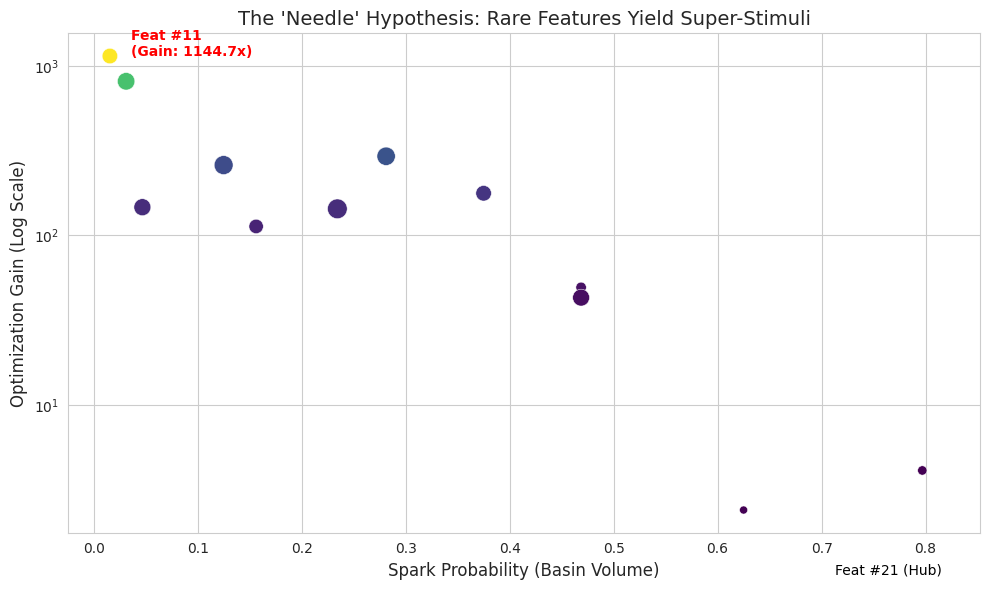

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Load the data
df = pd.read_csv("sae_geometry_scan.csv")

# Filter out the "Dead" features (Spark = 0)
df_active = df[df["spark_probability"] > 0].copy()

# Setup the plot
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# SCATTER PLOT: Spark Prob (X) vs Gain (Y)
# We use log scale for Gain because Feature 11 is so massive
sns.scatterplot(
    data=df_active,
    x="spark_probability",
    y="gain",
    size="max_opt_act",
    sizes=(20, 200),
    hue="gain",
    palette="viridis",
    legend=False
)

plt.title("The 'Needle' Hypothesis: Rare Features Yield Super-Stimuli", fontsize=14)
plt.xlabel("Spark Probability (Basin Volume)", fontsize=12)
plt.ylabel("Optimization Gain (Log Scale)", fontsize=12)
plt.yscale("log")

# Annotate the "Star" Features
# Feature 11 (The Massive Needle)
row_11 = df[df["feature_idx"] == 11].iloc[0]
plt.text(
    row_11["spark_probability"] + 0.02,
    row_11["gain"],
    f"Feat #11\n(Gain: {row_11['gain']:.1f}x)",
    color="red",
    fontweight="bold"
)

# Feature 21 (The Hub)
row_21 = df[df["feature_idx"] == 21].iloc[0]
plt.text(
    row_21["spark_probability"] - 0.1,
    1.0,
    f"Feat #21 (Hub)",
    color="black"
)

plt.tight_layout()
plt.show()

In [ ]:
# Run the deep dreamer on our "Star" feature
# We use high diversity weight to force it to show us the full concept
text_11 = deep_dream_last_token_robust(
    feature_idx=11,
    steps=150,
    reg_weight=1.0,
    div_weight=100.0
)


=== Context Dreaming for Feature #11 ===
Scanning 32 seeds (Manual Mode)...
Best initial last-token activation: 1.1273
Optimizing Candidate #12...
Step 000 | Act: 1.1 | DivLoss: 0.0084 | Text: [' Malfoy markup Reaper fringeland curs Hawkinsblood']
Step 025 | Act: 364.7 | DivLoss: -0.0622 | Text: [' Desmondoptions-)cape Trumpaughshun\x19']
Step 050 | Act: 732.8 | DivLoss: -0.0562 | Text: [' Brown transform-) " We\'"hun concess']
Step 075 | Act: 905.0 | DivLoss: -0.0600 | Text: [' Roose turnaround}}} " We\'"hun Huawei']
Step 100 | Act: 1036.4 | DivLoss: -0.0645 | Text: [' denies turnaround leftover " WeFourthTAG Huawei']
Step 125 | Act: 1123.6 | DivLoss: -0.0636 | Text: [' denies outcome thinner "\nFourthologically Pse']
Step 149 | Act: 1179.4 | DivLoss: -0.0637 | Text: [' denies outcome thinner <<\nFourthologically Pse']
